# PART 0: SETUP

## 0.1 Imports

In [1]:
# ▶ RUN THIS CELL: Import required libraries
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

# Figure settings for presentation-quality plots
plt.rcParams['figure.figsize'] = [12, 4]
plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.size'] = 16

print('✓ Imports successful!')

✓ Imports successful!


## 0.2 Load Connectome Data

We'll load synapse data from the **FAFB** (Full Adult Fly Brain) dataset, specifically the **central complex** region.

The data contains synaptic connections with columns:
- `pre`: presynaptic neuron ID
- `post`: postsynaptic neuron ID
- `side`: hemisphere (left/right)

In [ ]:
# ▶ RUN THIS CELL: Load connectome data
import os
import sys
import pandas as pd

# Make utils.py importable
sys.path.insert(0, os.path.dirname(os.path.abspath('.')))
from utils import construct_path, read_feather_gcs, subset_by_region, region_filter_spec

# Configuration
DATASET = 'fafb_783'
DATASET_ID = f'{DATASET}_id'
REGION = 'antennal_lobe'  # 'central_complex'
DATA_PATH = 'gs://lee-lab_brain-and-nerve-cord-fly-connectome/compiled_data'

# Per-region cut-out folders no longer exist in the new bucket. Load the full
# meta + edgelist for FAFB and build the regional subset in code, mirroring
# bancpipeline/banc/share/banc-sjcabs.R.
import gcsfs
gcs = gcsfs.GCSFileSystem(token='google_default')

meta_path     = construct_path(DATA_PATH, DATASET, 'meta')
edgelist_path = construct_path(DATA_PATH, DATASET, 'edgelist_simple')

print(f'Loading meta:     {meta_path}')
print(f'Loading edgelist: {edgelist_path}')

meta_df = read_feather_gcs(meta_path, gcs_fs=gcs)
edgelist_full = read_feather_gcs(edgelist_path, gcs_fs=gcs)

# Build the antennal_lobe (or central_complex) subset.
# antennal_lobe / central_complex are metadata-mode regions, so we don't need
# the synapse table — only meta is required.
sub = subset_by_region(meta_df, DATASET, REGION, edgelist=edgelist_full)
sub_ids = set(sub['ids'])
synapses_df = edgelist_full[edgelist_full['pre'].isin(sub_ids) & edgelist_full['post'].isin(sub_ids)].copy()

# Restrict meta_df to the subset for downstream cell-type / signed-edge code
meta_df = sub['meta'].copy()

print(f'\u2713 Loaded {len(synapses_df):,} edges in {REGION} subset')
print(f'  Columns: {list(synapses_df.columns)}')
synapses_df.head()


In [3]:
# Setup image directory
IMG_DIR = "images/tutorial_07"
os.makedirs(IMG_DIR, exist_ok=True)

print(f'Images will be saved to: {IMG_DIR}')

Images will be saved to: images/tutorial_07


In [4]:
# Add edges (multiple synapses between same neurons become edge weight)
edge_counts = synapses_df
# .groupby(['pre', 'post']).size().reset_index(name='weight')

In [5]:
from scipy import sparse

# Get unique node IDs and create mapping to indices
all_nodes = pd.unique(edge_counts[['pre', 'post']].values.ravel())
node_to_idx = {node: idx for idx, node in enumerate(all_nodes)}
n_nodes = len(all_nodes)

# Map pre/post to indices
row_indices = edge_counts['pre'].map(node_to_idx).values
col_indices = edge_counts['post'].map(node_to_idx).values
weights = edge_counts['norm'].values

# Create sparse adjacency matrix (CSR format for efficient row operations)
adj_matrix = sparse.csr_matrix((weights, (row_indices, col_indices)), shape=(n_nodes, n_nodes))

print(f'Sparse adjacency matrix: {adj_matrix.shape}')
print(f'  Non-zero entries: {adj_matrix.nnz:,}')
print(f'  Sparsity: {1 - adj_matrix.nnz / (n_nodes * n_nodes):.6f}')

Sparse adjacency matrix: (3532, 3532)
  Non-zero entries: 268,578
  Sparsity: 0.978471


# PART 1: Influence of perturbation of neuron $i$

$$\mathbf{V} = \mathbf{x} + g\mathbf{xJ} + g^2\mathbf{xJ^2} + g^3\mathbf{xJ^3} + \dots$$
where $\mathbf{x}$ is the perturbation vector with $x_i = 1, x_{k\neq i} = 0$. $\mathbf{J}$ is the weighted adjacency matrix (pre -> post; math convention).  

In [6]:
# ▶ RUN THIS CELL: Create perturbation vector for a particular cell type population

def create_perturbation_vector_from_celltype(meta_df, CELL_TYPE, node_to_idx, ID_COLUMN = f'{DATASET}_id'):
    # Get PFNp neuron IDs from metadata
    pfnp_ids = meta_df[meta_df['cell_type'] == CELL_TYPE][ID_COLUMN].values

    # Filter to neurons that exist in our adjacency matrix
    pfnp_ids_in_graph = [nid for nid in pfnp_ids if nid in node_to_idx]

    # Create perturbation vector: x_i = 1 for all PFNp neurons, 0 otherwise
    x = np.zeros(n_nodes)
    for nid in pfnp_ids_in_graph:
        x[node_to_idx[nid]] = 1

    return x

In [7]:
# Configuration
x = sparse.csr_array(create_perturbation_vector_from_celltype(meta_df, 'DM1_lPN', node_to_idx))

print(f'DM1_pn perturbation vector created:')
print(f'  Total DM1_pn neurons in metadata: {x.sum()}')
print(f'  Perturbation vector shape: {x.shape}')
print(f'  Non-zero entries: {int(x.sum())}')

DM1_pn perturbation vector created:
  Total DM1_pn neurons in metadata: 2.0
  Perturbation vector shape: (3532,)
  Non-zero entries: 2


In [8]:
# ▶ RUN THIS CELL: Compute perturbation influence V = x + gJx + g²J²x + ...

def compute_perturbation_influence(J, x, g=1, n_hops=10, transpose=False):
    """
    Compute the network influence to a perturbation using the power series:
    V = x + g*J*x + g²*J²*x + g³*J³*x + ... (up to n_hops)
    
    Parameters
    ----------
    J : sparse matrix
        Weighted adjacency matrix (n_nodes x n_nodes)
    x : sparse array or ndarray
        Perturbation vector (n_nodes,) or (1, n_nodes) with 1s for perturbed neurons
    g : float
        Gain/coupling constant. Controls how strongly activity propagates.
    n_hops : int
        Number of hops in the graph (k = 0, 1, ..., n_hops-1)
    transpose : bool
        If False: compute downstream effects (J propagates pre -> post)
        If True: compute upstream effects (J.T propagates post -> pre)
    
    Returns
    -------
    V : sparse array
        Influence vector (1, n_nodes) - activity level at each neuron
    terms : list of sparse arrays
        Individual terms [x, gJx, g²J²x, ...] for analysis
    """
    # Use transposed matrix if requested (for upstream propagation)
    J_eff = J.T if transpose else J
    
    # Ensure x is a sparse row vector (1, n_nodes) for matrix multiplication
    if sparse.issparse(x):
        if x.ndim == 1 or x.shape[0] != 1:
            x = sparse.csr_array(x.toarray().reshape(1, -1))
    else:
        x = sparse.csr_array(np.asarray(x).reshape(1, -1))

    # Initialize: V = x (k=0 term)
    V = x.copy()
    terms = [x.copy()]
    
    # Current term starts as x, will be updated as J^k * x
    current_term = x.copy()
    
    # Add terms: g^k * J^k * x for k = 1, 2, ..., n_hops-1
    # For row vector x: x @ J gives downstream propagation
    for k in range(1, n_hops+1):
        # x @ J^k = (x @ J^(k-1)) @ J
        current_term = current_term @ J_eff
        
        # g^k * J^k * x
        scaled_term = (g ** k) * current_term
        
        V = V + scaled_term
        terms.append(scaled_term.copy())
    
    return V, terms

In [9]:
# plt.hist(adj_matrix.toarray().sum(axis=0), bins=np.linspace(0,2,100))
# # np.sum((adj_matrix.sum(axis=1) < 1.05) & (adj_matrix.sum(axis=1) > 0.95))

In [10]:
# Example usage with the DM1_lPN perturbation
g = 1          # Gain constant
n_hops = 3     # Number of hops in graph

# Row-normalize the adjacency matrix (each row sums to 1)
# This normalizes by out-degree: J_normalized[i,j] = J[i,j] / sum(J[i,:])
# row_sums = np.array(adj_matrix.sum(axis=1)).flatten()
# row_sums[row_sums == 0] = 1  # Avoid division by zero for nodes with no outgoing edges
# inv_row_sums = sparse.diags(1.0 / row_sums)
# adj_matrix_norm = inv_row_sums @ adj_matrix
adj_matrix_norm = adj_matrix.copy()

V_downstream, terms_downstream = compute_perturbation_influence(
    adj_matrix_norm, x, g=g, n_hops=n_hops, transpose=False
)
V_upstream, terms_upstream = compute_perturbation_influence(
    adj_matrix_norm, x, g=g, n_hops=n_hops, transpose=True
)

print(f'Perturbation Influence Computed:')
print(f'  Parameters: g={g}, n_hops={n_hops}')
print(f'  Input neurons perturbed: {int(x.sum())}')
print(f'')
print(f'  Downstream (J): neurons with V > 0: {(V_downstream.toarray() > 0).sum()}')
print(f'  Downstream max influence: {V_downstream.max():.4f}')
print(f'')
print(f'  Upstream (J.T): neurons with V > 0: {(V_upstream.toarray() > 0).sum()}')
print(f'  Upstream max influence: {V_upstream.max():.4f}')

# Print nonzero entries at each hop level
print(f'\n--- Nonzero entries per hop (Downstream) ---')
for k, term in enumerate(terms_downstream):
    nnz = (term.toarray() > 0).sum()
    print(f'  Hop {k}: {nnz} nonzero entries')

print(f'\n--- Nonzero entries per hop (Upstream) ---')
for k, term in enumerate(terms_upstream):
    nnz = (term.toarray() > 0).sum()
    print(f'  Hop {k}: {nnz} nonzero entries')

Perturbation Influence Computed:
  Parameters: g=1, n_hops=3
  Input neurons perturbed: 2

  Downstream (J): neurons with V > 0: 3523
  Downstream max influence: 1.0192

  Upstream (J.T): neurons with V > 0: 3522
  Upstream max influence: 1.0199

--- Nonzero entries per hop (Downstream) ---
  Hop 0: 2 nonzero entries
  Hop 1: 338 nonzero entries
  Hop 2: 3514 nonzero entries
  Hop 3: 3523 nonzero entries

--- Nonzero entries per hop (Upstream) ---
  Hop 0: 2 nonzero entries
  Hop 1: 346 nonzero entries
  Hop 2: 3429 nonzero entries
  Hop 3: 3522 nonzero entries


In [11]:
# ▶ RUN THIS CELL: Plotly bar plot colored by g values with n_hops slider
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.colors as pc

# Create mapping from index to node ID
idx_to_node = {idx: node for node, idx in node_to_idx.items()}

# Get cell class for each node in the graph
ID_COLUMN = f'{DATASET}_id'
meta_lookup = meta_df.set_index(ID_COLUMN)['cell_class'].to_dict()

cell_classes = []
for i in range(n_nodes):
    node_id = idx_to_node[i]
    cc = meta_lookup.get(node_id)
    cell_classes.append(cc if cc is not None else 'Unknown')
cell_classes = np.array(cell_classes)

# Parameters
g_values = [.1, 0.5, 0.75, 1.0, 1.5, 2.0]
n_hops_values = [1, 2, 3, 4, 5, 6, 7, 8]

# Color map for g values
colors = pc.sample_colorscale('Viridis', [i / (len(g_values) - 1) for i in range(len(g_values))])

# Precompute influences for all combinations
all_results = {}
for n_hops in n_hops_values:
    all_results[n_hops] = {}
    for g_val in g_values:
        V_downstream, _ = compute_perturbation_influence(adj_matrix_norm, x, g=g_val, n_hops=n_hops, transpose=False)
        V_upstream, _ = compute_perturbation_influence(adj_matrix_norm, x, g=g_val, n_hops=n_hops, transpose=True)
        
        V_down = V_downstream.toarray().flatten()
        V_up = V_upstream.toarray().flatten()
        
        # Compute average V for each cell class
        unique_classes = np.unique(cell_classes)
        avg_downstream = {}
        avg_upstream = {}
        
        for cc in unique_classes:
            mask = cell_classes == cc
            if mask.sum() > 0:
                avg_downstream[cc] = V_down[mask].mean()
                avg_upstream[cc] = V_up[mask].mean()
        
        all_results[n_hops][g_val] = {'downstream': avg_downstream, 'upstream': avg_upstream}

print(f'Precomputed {len(n_hops_values)} n_hops x {len(g_values)} g values')

# Get all cell classes that have non-zero influence for any combination
all_classes = set()
for n_hops in n_hops_values:
    for g_val in g_values:
        for cc, val in all_results[n_hops][g_val]['downstream'].items():
            if val > 0:
                all_classes.add(cc)
        for cc, val in all_results[n_hops][g_val]['upstream'].items():
            if val > 0:
                all_classes.add(cc)

# Sort by downstream influence at g=1.0, n_hops=3
class_order = sorted(all_classes, key=lambda cc: all_results[3][1.0]['downstream'].get(cc, 0), reverse=True)

# Create figure
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=('Downstream Influence (J)', 'Upstream Influence (J.T)'),
    shared_yaxes=True,
    horizontal_spacing=0.15
)

# Add traces for each n_hops value (grouped by g)
default_n_hops = 3
traces_per_nhops = len(g_values) * 2  # downstream + upstream for each g

# Track trace indices for each g value (for legend interactivity)
trace_indices_by_g = {g_val: [] for g_val in g_values}

trace_count = 0
for n_hops in n_hops_values:
    visible = (n_hops == default_n_hops)
    
    for i, g_val in enumerate(g_values):
        # Downstream
        values_down = [all_results[n_hops][g_val]['downstream'].get(cc, 0) for cc in class_order]
        fig.add_trace(go.Bar(
            x=values_down,
            y=class_order,
            orientation='h',
            name=f'g={g_val}',
            marker_color=colors[i],
            opacity=0.8,
            visible=visible,
            legendgroup=f'g={g_val}',
            showlegend=False
        ), row=1, col=1)
        trace_indices_by_g[g_val].append(trace_count)
        trace_count += 1
        
        # Upstream
        values_up = [all_results[n_hops][g_val]['upstream'].get(cc, 0) for cc in class_order]
        fig.add_trace(go.Bar(
            x=values_up,
            y=class_order,
            orientation='h',
            name=f'g={g_val}',
            marker_color=colors[i],
            opacity=0.8,
            visible=visible,
            legendgroup=f'g={g_val}',
            showlegend=False
        ), row=1, col=2)
        trace_indices_by_g[g_val].append(trace_count)
        trace_count += 1

# Add dummy traces for legend (always visible, no data)
for i, g_val in enumerate(g_values):
    fig.add_trace(go.Bar(
        x=[None],
        y=[None],
        name=f'g={g_val}',
        marker_color=colors[i],
        legendgroup=f'g={g_val}',
        showlegend=True,
        visible=True
    ))

# Create slider steps
steps = []
total_traces = len(n_hops_values) * traces_per_nhops
for idx, n_hops in enumerate(n_hops_values):
    visibility = [False] * total_traces + [True] * len(g_values)  # Keep legend traces visible
    # Show all traces for this n_hops
    start_idx = idx * traces_per_nhops
    for i in range(traces_per_nhops):
        visibility[start_idx + i] = True
    
    step = dict(
        method='update',
        args=[{'visible': visibility},
              {'title': f'Perturbation Influence by Cell Class (n_hops={n_hops})'}],
        label=str(n_hops)
    )
    steps.append(step)

# Layout
fig.update_layout(
    title=f'Perturbation Influence by Cell Class (n_hops={default_n_hops})',
    height=750,
    barmode='group',
    showlegend=True,
    legend=dict(
        orientation='h',
        yanchor='bottom',
        y=1.08,
        xanchor='center',
        x=0.5,
        title=dict(text='Click to toggle g values:', font=dict(size=12)),
        font=dict(size=12),
        bgcolor='rgba(255,255,255,0.9)',
        bordercolor='gray',
        borderwidth=1,
        itemclick='toggle',
        itemdoubleclick='toggleothers'
    ),
    sliders=[dict(
        active=n_hops_values.index(default_n_hops),
        currentvalue={'prefix': 'n_hops = ', 'visible': True, 'xanchor': 'center'},
        pad={'t': 60},
        steps=steps
    )],
    margin=dict(t=120)
)

fig.update_xaxes(title_text='Average Influence V', row=1, col=1)
fig.update_xaxes(title_text='Average Influence V', row=1, col=2)
fig.update_yaxes(title_text='Cell Class', row=1, col=1)

fig.show()

Precomputed 8 n_hops x 6 g values


# PART 4: Validation Against Frechter et al. 2019 Data

We'll validate our linear model predictions against experimentally measured odor responses in Lateral Horn Neurons (LHNs) from Frechter et al. eLife 2019.

**Data sources:**
- `frechter_2019_lhn_spikes_simple.csv`: LHN spike responses to odors
- `door_database_orn_responses_normalised.csv`: ORN responses to odors from DoOR database

**Approach:**
1. Create signed adjacency matrix (acetylcholine = excitatory, others = inhibitory)
2. Weight E:I ratio as 1:10
3. For each odor, stimulate ORNs based on DoOR data
4. Compute forward influence to LHNs (g=1.0, 4 hops)
5. Compare predictions to experimental LHN responses using ROC analysis

In [12]:
# ▶ Load validation data
print('Loading Frechter et al. 2019 validation data...')

# Odor mapping file
odour_mapping_path = 'gs://lee-lab_brain-and-nerve-cord-fly-connectome/compiled_data/behaviour/frechter_et_al_2019/frechter_2019_odours.csv'
if os.path.exists('data/frechter_2019_odours.csv'):
    odour_mapping = pd.read_csv('data/frechter_2019_odours.csv')
else:
    with gcs.open(odour_mapping_path.replace('gs://', ''), 'rb') as f:
        odour_mapping = pd.read_csv(f)

print(f'✓ Loaded odour mapping: {len(odour_mapping)} odours')

# LHN responses to odors
lhn_responses_path = 'gs://lee-lab_brain-and-nerve-cord-fly-connectome/compiled_data/behaviour/frechter_et_al_2019/frechter_2019_lhn_spikes_simple.csv'
if os.path.exists('data/frechter_2019_lhn_spikes_simple.csv'):
    lhn_responses = pd.read_csv('data/frechter_2019_lhn_spikes_simple.csv')
else:
    with gcs.open(lhn_responses_path.replace('gs://', ''), 'rb') as f:
        lhn_responses = pd.read_csv(f)

print(f'✓ Loaded LHN responses: {lhn_responses.shape}')

# Convert odor response columns to numeric (they are stored as strings)
odor_cols = [col for col in lhn_responses.columns if col not in ["cell_type"]]
for col in odor_cols:
    lhn_responses[col] = pd.to_numeric(lhn_responses[col], errors="coerce")

print(f'  Cell types: {lhn_responses["cell_type"].nunique()}')

# ORN responses from DoOR database
door_responses_path = 'gs://lee-lab_brain-and-nerve-cord-fly-connectome/compiled_data/behaviour/frechter_et_al_2019/door_database_orn_responses_normalised.csv'
if os.path.exists('data/door_database_orn_responses_normalised.csv'):
    door_responses = pd.read_csv('data/door_database_orn_responses_normalised.csv')
else:
    with gcs.open(door_responses_path.replace('gs://', ''), 'rb') as f:
        door_responses = pd.read_csv(f)

# Add odor codes as index using mapping file
door_responses['odour_code'] = odour_mapping['code'].values[:len(door_responses)]
door_responses = door_responses.set_index('odour_code')

print(f'✓ Loaded DoOR ORN responses: {door_responses.shape}')
print(f'  Odors (with codes): {len(door_responses)}')
print(f'  ORN types: {len(door_responses.columns)}')
print(f'  Sample odor codes: {list(door_responses.index[:5])}')

# Display sample
print('\nSample LHN data:')
display(lhn_responses.head())
print('\nSample DoOR data:')
display(door_responses.head())

Loading Frechter et al. 2019 validation data...
✓ Loaded odour mapping: 53 odours


✓ Loaded LHN responses: (145, 52)
  Cell types: 80
✓ Loaded DoOR ORN responses: (31, 47)
  Odors (with codes): 31
  ORN types: 47
  Sample odor codes: ['OilBl', 'WatBl', 'Blank1', 'Blank2', 'Blank3']

Sample LHN data:


,OilBl,6728-26-3,105-87-3,109-60-4,123-92-2,5405-41-4,124-19-6,6186-98-7,119-36-8,142-92-7,...,431‑03‑8,4630‑07‑3,111‑82‑0,112‑39‑0,124‑10‑7,2785‑89‑9,124‑19‑6,124‑19‑6.1,Blank3,cell_type
0,2,11,25,32,35,63,12,49,53,46,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,LHPV5a1
1,1,13,12,7,10,4,22,29,8,3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,AOTU008d
2,4,13,15,2,18,10,23,23,0,10,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,AOTU008d
3,3,0,0,12,6,20,0,4,5,5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CB2910
4,1,12,10,18,15,18,3,14,8,2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,LHPV5a1



Sample DoOR data:


,ORN_DA4m,ORN_DL5,ORN_VM3,ORN_DL1,ORN_DC2,ORN_DC1,ORN_DM2,ORN_DM2.1,ORN_DA3,ORN_DM5,...,ORN_D,ORN_VL2p,ORN_VC5,ORN_DL2d/DL2v/Dp1l,ORN_VM4,ORN_VL2a,ORN_VM1,ORN_DC4,ORN_DP1m,ORN_DC3
odour_code,,,,,,,,,,,,,,,,,,,,,
OilBl,0.026823,0.083497,0.064345,0.052190,0.026290,0.103613,0.093448,NaN,0.019317,0.050309,...,0.0,0.116693,0.162659,0.084343,0.044802,0.190936,0.075637,0.000000,0.015990,0.078341
WatBl,0.039537,0.032775,0.097870,0.058137,0.171888,0.025436,0.061758,NaN,0.015024,0.029070,...,NaN,0.139446,0.490748,0.274386,0.028581,0.178187,0.030773,0.326230,0.147709,NaN
Blank1,0.027169,0.017649,0.139903,0.075210,NaN,0.022893,0.015227,NaN,0.004293,0.023461,...,NaN,0.073242,0.413655,0.196254,0.034487,0.182221,0.039928,0.293186,0.101904,NaN
Blank2,NaN,0.037884,NaN,0.141263,0.120057,NaN,0.023503,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.170507
Blank3,0.037012,0.084810,0.103747,0.025392,0.059563,0.025436,0.106142,NaN,0.017170,0.032869,...,0.0,0.045646,0.294425,0.644235,0.000000,0.186009,0.008521,1.000000,0.490998,0.115207


In [13]:
# ▶ Create signed adjacency matrix based on neurotransmitter
print('Creating signed adjacency matrix...')

# Determine sign for each neuron based on neurotransmitter
# Acetylcholine = excitatory (+1), everything else = inhibitory (-1)
meta_df['sign'] = -1  # Default to inhibitory
meta_df.loc[meta_df['neurotransmitter_predicted'] == 'acetylcholine', 'sign'] = 1

print(f'Excitatory neurons (ACh): {(meta_df["sign"] == 1).sum():,}')
print(f'Inhibitory neurons (other): {(meta_df["sign"] == -1).sum():,}')

# Create neuron ID to sign mapping
id_to_sign = dict(zip(meta_df[f'{DATASET}_id'], meta_df['sign']))

# Map signs to adjacency matrix entries based on presynaptic neuron
row_signs = np.array([id_to_sign.get(all_nodes[idx], -1) for idx in row_indices])

# Apply E:I weighting (1:10 ratio)
# Excitatory synapses get weight 1, inhibitory get weight -10
ei_weights = np.where(row_signs == 1, 1.0, -10.0)

# Create signed weighted adjacency matrix
signed_weights = weights * row_signs * np.abs(ei_weights)
adj_matrix_signed = sparse.csr_matrix(
    (signed_weights, (row_indices, col_indices)),
    shape=(n_nodes, n_nodes)
)

print(f'\n✓ Created signed adjacency matrix: {adj_matrix_signed.shape}')
print(f'  Positive (excitatory) connections: {(signed_weights > 0).sum():,}')
print(f'  Negative (inhibitory) connections: {(signed_weights < 0).sum():,}')
print(f'  E:I ratio in weights: {np.abs(signed_weights[signed_weights > 0].sum() / signed_weights[signed_weights < 0].sum()):.2f}')

Creating signed adjacency matrix...
Excitatory neurons (ACh): 2,281
Inhibitory neurons (other): 1,252

✓ Created signed adjacency matrix: (3532, 3532)
  Positive (excitatory) connections: 145,713
  Negative (inhibitory) connections: 122,299
  E:I ratio in weights: 0.04


In [14]:
# ▶ Map cell types to neuron IDs
print('Mapping cell types to neuron IDs...')

# Get ORN cell types from DoOR database
orn_types_door = door_responses.columns.tolist()
print(f'ORN types in DoOR: {len(orn_types_door)}')

# Map ORN cell types to neuron IDs in our graph
orn_type_to_ids = {}
for orn_type in orn_types_door:
    # Try to match cell type in metadata
    matching_neurons = meta_df[
        meta_df['cell_type'].str.contains(orn_type, case=False, na=False, regex=False)
    ][f'{DATASET}_id'].values
    
    # Filter to neurons in our graph
    matching_in_graph = [nid for nid in matching_neurons if nid in node_to_idx]
    
    if len(matching_in_graph) > 0:
        orn_type_to_ids[orn_type] = matching_in_graph

print(f'✓ Mapped {len(orn_type_to_ids)} ORN types to graph neurons')
print(f'  Total ORN neurons: {sum(len(ids) for ids in orn_type_to_ids.values())}')

# Map LHN cell types to neuron IDs
lhn_types = lhn_responses['cell_type'].unique()
print(f'\nLHN types in Frechter data: {len(lhn_types)}')

lhn_type_to_ids = {}
for lhn_type in lhn_types:
    if pd.isna(lhn_type):
        continue
    
    # Try exact match first
    matching_neurons = meta_df[
        meta_df['cell_type'] == lhn_type
    ][f'{DATASET}_id'].values
    
    # If no exact match, try partial match
    if len(matching_neurons) == 0:
        matching_neurons = meta_df[
            meta_df['cell_type'].str.contains(lhn_type, case=False, na=False, regex=False)
        ][f'{DATASET}_id'].values
    
    # Filter to neurons in our graph
    matching_in_graph = [nid for nid in matching_neurons if nid in node_to_idx]
    
    if len(matching_in_graph) > 0:
        lhn_type_to_ids[lhn_type] = matching_in_graph

print(f'✓ Mapped {len(lhn_type_to_ids)} LHN types to graph neurons')
print(f'  Total LHN neurons: {sum(len(ids) for ids in lhn_type_to_ids.values())}')

# Show some examples
print(f'\nExample ORN mappings:')
for orn_type in list(orn_type_to_ids.keys())[:3]:
    print(f'  {orn_type}: {len(orn_type_to_ids[orn_type])} neurons')

print(f'\nExample LHN mappings:')
for lhn_type in list(lhn_type_to_ids.keys())[:3]:
    print(f'  {lhn_type}: {len(lhn_type_to_ids[lhn_type])} neurons')

Mapping cell types to neuron IDs...
ORN types in DoOR: 47
✓ Mapped 44 ORN types to graph neurons
  Total ORN neurons: 4210

LHN types in Frechter data: 80
✓ Mapped 2 LHN types to graph neurons
  Total LHN neurons: 5

Example ORN mappings:
  ORN_DA4m: 40 neurons
  ORN_DL5: 42 neurons
  ORN_VM3: 37 neurons

Example LHN mappings:
  M_lvPNm29: 3 neurons
  VP2_l2PN: 2 neurons


In [15]:
# ▶ Run linear model predictions for each odor
print('Running linear model predictions...')

# Parameters
g = 1.0
n_hops = 4

# Get odors that are in both datasets (using odor codes)
lhn_odor_cols = [col for col in lhn_responses.columns 
                 if col not in ['cell_type', 'Blank1', 'Blank2']]
door_odor_codes = door_responses.index.tolist()

# Find common odors (only CAS numbers - numeric codes like '6728-26-3')
# Drop blanks and named odors
import re
def is_cas_number(s):
    # CAS numbers are like 6728-26-3 or 105-87-3
    return bool(re.match(r'^\d+-\d+-\d+$', str(s)))

common_odors = [odor for odor in lhn_odor_cols 
                if odor in door_odor_codes and is_cas_number(odor)]

print(f'LHN odor columns: {len(lhn_odor_cols)}')
print(f'DoOR odor codes: {len(door_odor_codes)}')
print(f'Common odors: {len(common_odors)}')
print(f'Examples: {common_odors[:5]}')

# Calculate baseline LHN activity (mean of Blank1, Blank2, and OilBl)
# Fill NaN with 0 (missing blank measurements treated as 0 spikes)
blank_cols = ['Blank1', 'Blank2', 'OilBl']
lhn_responses['baseline'] = lhn_responses[blank_cols].fillna(0).mean(axis=1)

# Store predictions and ground truth
predictions = {}  # {lhn_type: {odor: predicted_influence}}
ground_truth = {}  # {lhn_type: {odor: measured_spikes - baseline}}

# Initialize for all LHN types we mapped
for lhn_type in lhn_type_to_ids.keys():
    predictions[lhn_type] = {}
    ground_truth[lhn_type] = {}

# Process each odor
for odor_idx, odor in enumerate(common_odors):
    if odor_idx % 5 == 0:
        print(f'  Processing odor {odor_idx+1}/{len(common_odors)}: {odor}')
    
    # Get ORN responses for this odor from DoOR
    orn_responses_door = door_responses.loc[odor]
    
    # Create perturbation vector with ORN response magnitudes
    x = np.zeros(n_nodes)
    for orn_type, response in orn_responses_door.items():
        if pd.notna(response) and orn_type in orn_type_to_ids:
            orn_ids = orn_type_to_ids[orn_type]
            for nid in orn_ids:
                x[node_to_idx[nid]] = response
    
    # Skip if no ORN responses
    if x.sum() == 0:
        continue
    
    # Compute forward influence
    x_sparse = sparse.csr_array(x.reshape(1, -1))
    V, _ = compute_perturbation_influence(
        adj_matrix_signed,
        x_sparse,
        g=g,
        n_hops=n_hops,
        transpose=False  # Forward propagation
    )
    
    V_array = V.toarray().flatten()
    
    # Extract influence for each LHN type
    for lhn_type in lhn_type_to_ids.keys():
        lhn_ids = lhn_type_to_ids[lhn_type]
        
        # Average influence across all neurons of this type
        lhn_influences = [V_array[node_to_idx[nid]] for nid in lhn_ids]
        avg_influence = np.mean(lhn_influences)
        predictions[lhn_type][odor] = avg_influence
        
        # Get ground truth (measured spikes minus baseline)
        lhn_row = lhn_responses[lhn_responses['cell_type'] == lhn_type]
        if len(lhn_row) > 0 and odor in lhn_row.columns:
            measured_spikes = lhn_row[odor].values[0]
            baseline = lhn_row['baseline'].values[0]
            ground_truth[lhn_type][odor] = measured_spikes - baseline

print(f'\n✓ Completed predictions for {len(common_odors)} odors')
print(f'  LHN types with predictions: {len([k for k, v in predictions.items() if len(v) > 0])}')

# Check prediction counts
total_pairs = sum(len(v) for v in predictions.values())
print(f'  Total prediction-observation pairs: {total_pairs}')

Running linear model predictions...
LHN odor columns: 49
DoOR odor codes: 31
Common odors: 24
Examples: ['6728-26-3', '105-87-3', '109-60-4', '123-92-2', '5405-41-4']
  Processing odor 1/24: 6728-26-3
  Processing odor 6/24: 124-19-6
  Processing odor 11/24: 4906-24-5


  Processing odor 16/24: 111-27-3
  Processing odor 21/24: 79-20-9

✓ Completed predictions for 24 odors
  LHN types with predictions: 2
  Total prediction-observation pairs: 46


## Parameter Sweep

Sweep over hyperparameters to find optimal values:
- **g** (gain): [0.5, 0.75, 1.0, 1.25, 1.5]
- **n_hops**: [2, 3, 4, 5, 6]
- **E:I ratio**: [1:5, 1:10, 1:15, 1:20]

In [16]:
# ▶ Parameter sweep to find optimal hyperparameters
from sklearn.metrics import roc_auc_score
from itertools import product

print('Running parameter sweep...')

# Define parameter ranges
g_values = [0.5, 0.75, 1.0, 1.25, 1.5]
n_hops_values = [2, 3, 4, 5, 6]
ei_ratios = [5, 10, 15, 20]  # Inhibition weight (excitation is always 1)

print(f'Testing {len(g_values)} × {len(n_hops_values)} × {len(ei_ratios)} = {len(g_values)*len(n_hops_values)*len(ei_ratios)} parameter combinations')

# Store results
sweep_results = []

# Sweep over all combinations
total_combinations = len(g_values) * len(n_hops_values) * len(ei_ratios)
combo_idx = 0

for ei_ratio in ei_ratios:
    print(f'\n  Testing E:I ratio 1:{ei_ratio}...')
    
    # Recreate signed adjacency matrix with this E:I ratio
    ei_weights = np.where(row_signs == 1, 1.0, -ei_ratio)
    signed_weights_sweep = weights * row_signs * np.abs(ei_weights)
    adj_matrix_sweep = sparse.csr_matrix(
        (signed_weights_sweep, (row_indices, col_indices)),
        shape=(n_nodes, n_nodes)
    )
    
    for g in g_values:
        for n_hops in n_hops_values:
            combo_idx += 1
            if combo_idx % 20 == 0:
                print(f'    Progress: {combo_idx}/{total_combinations} ({100*combo_idx/total_combinations:.1f}%)')
            
            # Run predictions with these parameters
            predictions_sweep = {}
            ground_truth_sweep = {}
            
            for lhn_type in lhn_type_to_ids.keys():
                predictions_sweep[lhn_type] = {}
                ground_truth_sweep[lhn_type] = {}
            
            # Process each odor
            for odor in common_odors:
                # Get ORN responses
                orn_responses_door = door_responses.loc[odor]
                
                # Create perturbation vector
                x = np.zeros(n_nodes)
                for orn_type, response in orn_responses_door.items():
                    if pd.notna(response) and orn_type in orn_type_to_ids:
                        for nid in orn_type_to_ids[orn_type]:
                            x[node_to_idx[nid]] = response
                
                if x.sum() == 0:
                    continue
                
                # Compute influence
                x_sparse = sparse.csr_array(x.reshape(1, -1))
                V, _ = compute_perturbation_influence(
                    adj_matrix_sweep, x_sparse, g=g, n_hops=n_hops, transpose=False
                )
                V_array = V.toarray().flatten()
                
                # Extract LHN influences
                for lhn_type in lhn_type_to_ids.keys():
                    lhn_ids = lhn_type_to_ids[lhn_type]
                    lhn_influences = [V_array[node_to_idx[nid]] for nid in lhn_ids]
                    predictions_sweep[lhn_type][odor] = np.mean(lhn_influences)
                    
                    # Get ground truth
                    lhn_row = lhn_responses[lhn_responses['cell_type'] == lhn_type]
                    if len(lhn_row) > 0 and odor in lhn_row.columns:
                        measured = lhn_row[odor].values[0]
                        baseline = lhn_row['baseline'].values[0]
                        ground_truth_sweep[lhn_type][odor] = measured - baseline
            
            # Compute ROC AUC for this combination
            all_preds = []
            all_labels = []
            
            for lhn_type in predictions_sweep.keys():
                for odor in predictions_sweep[lhn_type].keys():
                    if odor in ground_truth_sweep[lhn_type]:
                        pred = predictions_sweep[lhn_type][odor]
                        true = ground_truth_sweep[lhn_type][odor]
                        
                        if not pd.isna(true):
                            all_preds.append(pred)
                            all_labels.append(1 if true > 0 else 0)
            
            # Calculate ROC AUC if we have both classes
            if len(np.unique(all_labels)) > 1:
                roc_auc = roc_auc_score(all_labels, all_preds)
            else:
                roc_auc = np.nan
            
            # Store result
            sweep_results.append({
                'g': g,
                'n_hops': n_hops,
                'ei_ratio': ei_ratio,
                'roc_auc': roc_auc,
                'n_pairs': len(all_preds)
            })

# Convert to DataFrame
sweep_df = pd.DataFrame(sweep_results)

# Find best parameters
best_idx = sweep_df['roc_auc'].idxmax()
best_params = sweep_df.loc[best_idx]

print(f'\n✓ Parameter sweep complete!')
print(f'\nBest parameters:')
print(f'  g = {best_params["g"]}')
print(f'  n_hops = {int(best_params["n_hops"])}')
print(f'  E:I ratio = 1:{int(best_params["ei_ratio"])}')
print(f'  ROC AUC = {best_params["roc_auc"]:.3f}')

# Show top 10 parameter combinations
print(f'\nTop 10 parameter combinations:')
top_10 = sweep_df.nlargest(10, 'roc_auc')
display(top_10)

Running parameter sweep...
Testing 5 × 5 × 4 = 100 parameter combinations

  Testing E:I ratio 1:5...


    Progress: 20/100 (20.0%)



  Testing E:I ratio 1:10...


    Progress: 40/100 (40.0%)



  Testing E:I ratio 1:15...


    Progress: 60/100 (60.0%)



  Testing E:I ratio 1:20...


    Progress: 80/100 (80.0%)


    Progress: 100/100 (100.0%)

✓ Parameter sweep complete!

Best parameters:
  g = 0.5
  n_hops = 4
  E:I ratio = 1:5
  ROC AUC = 0.802

Top 10 parameter combinations:


,g,n_hops,ei_ratio,roc_auc,n_pairs
2,0.50,4,5,0.802198,46
4,0.50,6,5,0.794872,46
25,0.50,2,10,0.769231,46
0,0.50,2,5,0.761905,46
5,0.75,2,5,0.754579,46
20,1.50,2,5,0.747253,46
3,0.50,5,5,0.747253,46
50,0.50,2,15,0.747253,46
30,0.75,2,10,0.743590,46
10,1.00,2,5,0.743590,46


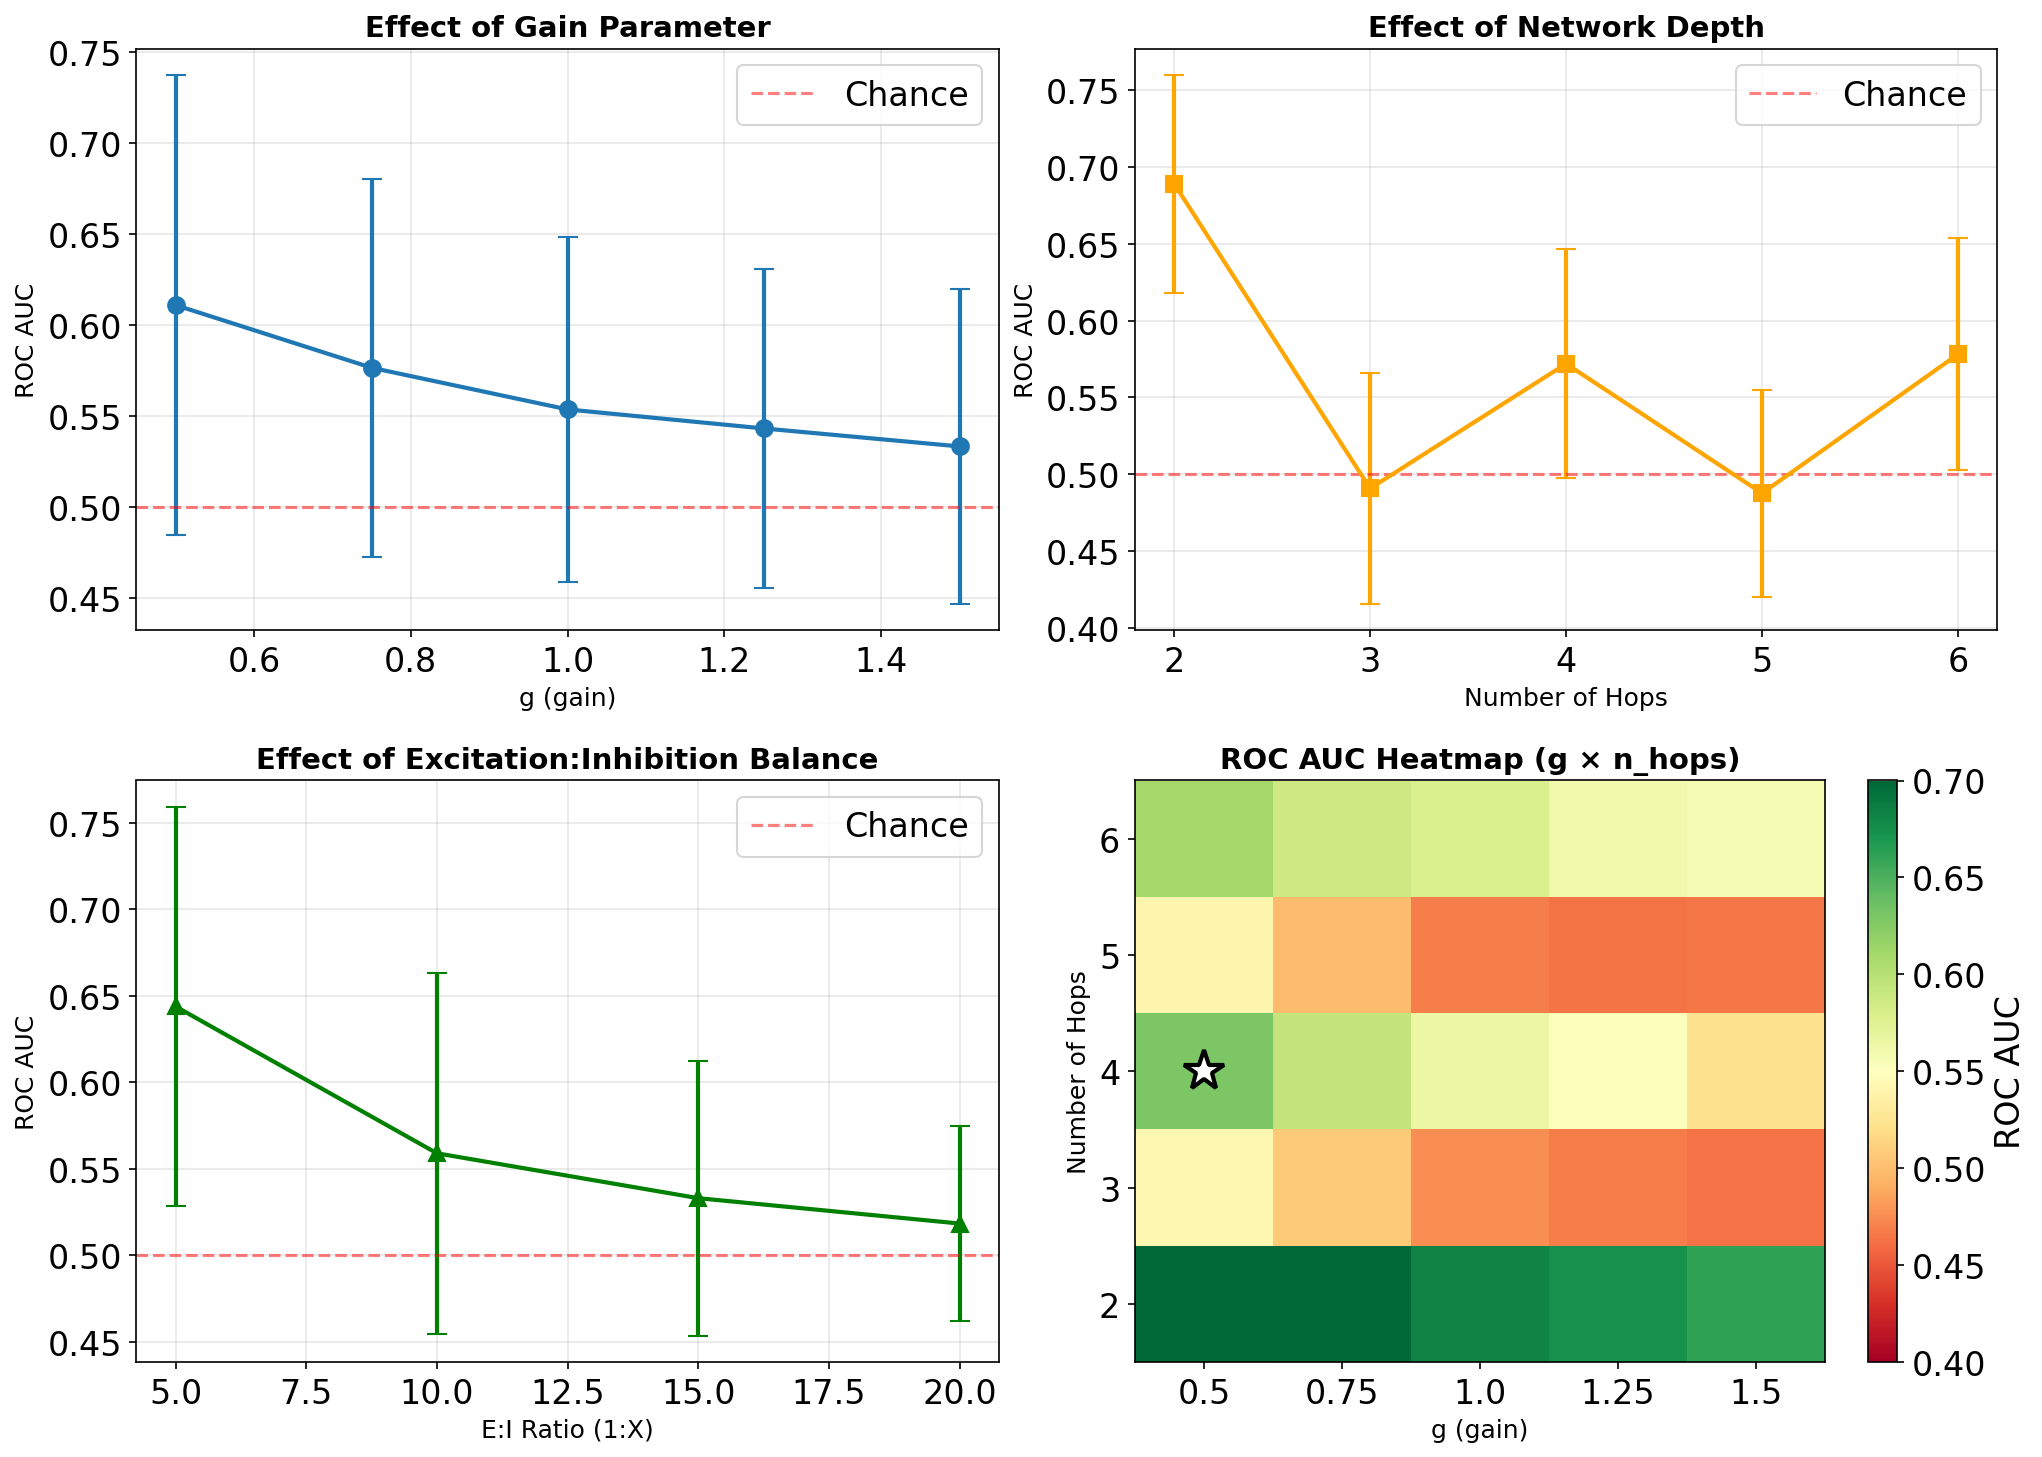

✓ Saved parameter sweep visualization


In [17]:
# ▶ Visualize parameter sweep results
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. ROC AUC vs g (averaged over other params)
g_grouped = sweep_df.groupby('g')['roc_auc'].agg(['mean', 'std'])
axes[0, 0].errorbar(g_grouped.index, g_grouped['mean'], yerr=g_grouped['std'], 
                    marker='o', capsize=5, linewidth=2, markersize=8)
axes[0, 0].axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='Chance')
axes[0, 0].set_xlabel('g (gain)', fontsize=12)
axes[0, 0].set_ylabel('ROC AUC', fontsize=12)
axes[0, 0].set_title('Effect of Gain Parameter', fontsize=14, fontweight='bold')
axes[0, 0].grid(alpha=0.3)
axes[0, 0].legend()

# 2. ROC AUC vs n_hops
hops_grouped = sweep_df.groupby('n_hops')['roc_auc'].agg(['mean', 'std'])
axes[0, 1].errorbar(hops_grouped.index, hops_grouped['mean'], yerr=hops_grouped['std'],
                    marker='s', capsize=5, linewidth=2, markersize=8, color='orange')
axes[0, 1].axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='Chance')
axes[0, 1].set_xlabel('Number of Hops', fontsize=12)
axes[0, 1].set_ylabel('ROC AUC', fontsize=12)
axes[0, 1].set_title('Effect of Network Depth', fontsize=14, fontweight='bold')
axes[0, 1].grid(alpha=0.3)
axes[0, 1].legend()

# 3. ROC AUC vs E:I ratio
ei_grouped = sweep_df.groupby('ei_ratio')['roc_auc'].agg(['mean', 'std'])
axes[1, 0].errorbar(ei_grouped.index, ei_grouped['mean'], yerr=ei_grouped['std'],
                    marker='^', capsize=5, linewidth=2, markersize=8, color='green')
axes[1, 0].axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='Chance')
axes[1, 0].set_xlabel('E:I Ratio (1:X)', fontsize=12)
axes[1, 0].set_ylabel('ROC AUC', fontsize=12)
axes[1, 0].set_title('Effect of Excitation:Inhibition Balance', fontsize=14, fontweight='bold')
axes[1, 0].grid(alpha=0.3)
axes[1, 0].legend()

# 4. Heatmap: g vs n_hops (averaged over E:I)
heatmap_data = sweep_df.groupby(['g', 'n_hops'])['roc_auc'].mean().unstack()
im = axes[1, 1].imshow(heatmap_data.T, aspect='auto', cmap='RdYlGn', 
                       vmin=0.4, vmax=0.7, origin='lower')
axes[1, 1].set_xticks(range(len(heatmap_data.index)))
axes[1, 1].set_xticklabels(heatmap_data.index)
axes[1, 1].set_yticks(range(len(heatmap_data.columns)))
axes[1, 1].set_yticklabels(heatmap_data.columns)
axes[1, 1].set_xlabel('g (gain)', fontsize=12)
axes[1, 1].set_ylabel('Number of Hops', fontsize=12)
axes[1, 1].set_title('ROC AUC Heatmap (g × n_hops)', fontsize=14, fontweight='bold')
plt.colorbar(im, ax=axes[1, 1], label='ROC AUC')

# Mark best point
best_g_idx = list(heatmap_data.index).index(best_params['g'])
best_hops_idx = list(heatmap_data.columns).index(best_params['n_hops'])
axes[1, 1].plot(best_g_idx, best_hops_idx, 'w*', markersize=20, 
                markeredgecolor='black', markeredgewidth=2)

plt.tight_layout()
plt.savefig(f'{IMG_DIR}/parameter_sweep_results.png', dpi=300, bbox_inches='tight')
plt.show()

print('✓ Saved parameter sweep visualization')

=== Running Best Model ===
Using optimal parameters: g=0.5, n_hops=4, E:I=1:5
✓ Computed predictions with best parameters

=== Best Model Statistics ===
Prediction-observation pairs: 46

Prediction statistics:
  Min: -0.0270
  Max: 0.0036
  Mean: -0.0027
  Std: 0.0064

Ground truth statistics:
  Min: -1.3333
  Max: 119.6667
  Mean: 9.3551
  Std: 17.8752


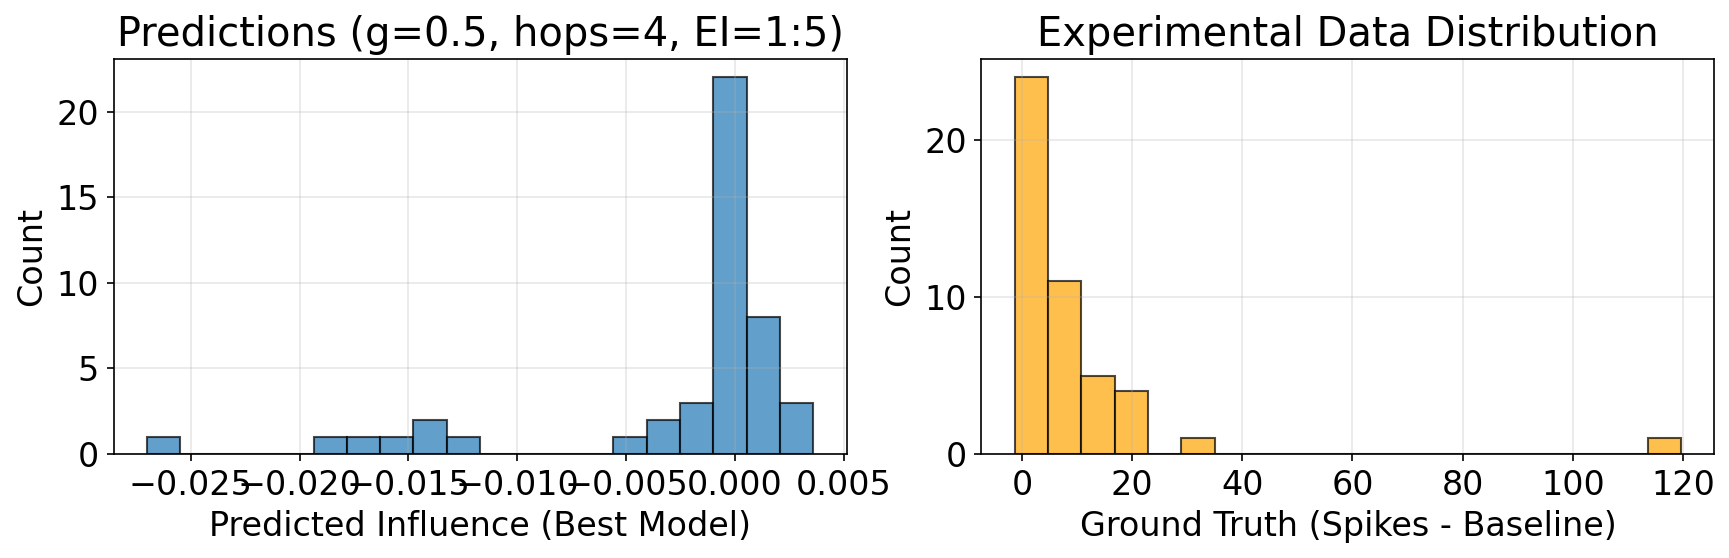

In [18]:
# ▶ Recompute predictions with best parameters
print('=== Running Best Model ===' )
print(f'Using optimal parameters: g={best_params["g"]}, n_hops={int(best_params["n_hops"])}, E:I=1:{int(best_params["ei_ratio"])}')

# Recreate adjacency matrix with best E:I ratio
best_ei_ratio = int(best_params['ei_ratio'])
ei_weights_best = np.where(row_signs == 1, 1.0, -best_ei_ratio)
signed_weights_best = weights * row_signs * np.abs(ei_weights_best)
adj_matrix_best = sparse.csr_matrix(
    (signed_weights_best, (row_indices, col_indices)),
    shape=(n_nodes, n_nodes)
)

# Run predictions with best parameters
predictions_best = {}
ground_truth_best = {}

for lhn_type in lhn_type_to_ids.keys():
    predictions_best[lhn_type] = {}
    ground_truth_best[lhn_type] = {}

for odor in common_odors:
    orn_responses_door = door_responses.loc[odor]
    
    x = np.zeros(n_nodes)
    for orn_type, response in orn_responses_door.items():
        if pd.notna(response) and orn_type in orn_type_to_ids:
            for nid in orn_type_to_ids[orn_type]:
                x[node_to_idx[nid]] = response
    
    if x.sum() == 0:
        continue
    
    x_sparse = sparse.csr_array(x.reshape(1, -1))
    V, _ = compute_perturbation_influence(
        adj_matrix_best, x_sparse, 
        g=best_params['g'], 
        n_hops=int(best_params['n_hops']), 
        transpose=False
    )
    V_array = V.toarray().flatten()
    
    for lhn_type in lhn_type_to_ids.keys():
        lhn_ids = lhn_type_to_ids[lhn_type]
        lhn_influences = [V_array[node_to_idx[nid]] for nid in lhn_ids]
        predictions_best[lhn_type][odor] = np.mean(lhn_influences)
        
        lhn_row = lhn_responses[lhn_responses['cell_type'] == lhn_type]
        if len(lhn_row) > 0 and odor in lhn_row.columns:
            measured = lhn_row[odor].values[0]
            baseline = lhn_row['baseline'].values[0]
            ground_truth_best[lhn_type][odor] = measured - baseline

print('✓ Computed predictions with best parameters')

# Extract values for analysis
pred_values = []
truth_values = []
for lhn_type in predictions_best.keys():
    for odor in predictions_best[lhn_type].keys():
        if odor in ground_truth_best[lhn_type]:
            pred = predictions_best[lhn_type][odor]
            true = ground_truth_best[lhn_type][odor]
            if not pd.isna(true):
                pred_values.append(pred)
                truth_values.append(true)

pred_values = np.array(pred_values)
truth_values = np.array(truth_values)

print(f'\n=== Best Model Statistics ===')
print(f'Prediction-observation pairs: {len(pred_values)}')
print(f'\nPrediction statistics:')
print(f'  Min: {np.min(pred_values):.4f}')
print(f'  Max: {np.max(pred_values):.4f}')
print(f'  Mean: {np.mean(pred_values):.4f}')
print(f'  Std: {np.std(pred_values):.4f}')

print(f'\nGround truth statistics:')
print(f'  Min: {np.min(truth_values):.4f}')
print(f'  Max: {np.max(truth_values):.4f}')
print(f'  Mean: {np.mean(truth_values):.4f}')
print(f'  Std: {np.std(truth_values):.4f}')

# Plot distributions
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(pred_values, bins=20, alpha=0.7, edgecolor='black')
axes[0].set_xlabel('Predicted Influence (Best Model)')
axes[0].set_ylabel('Count')
axes[0].set_title(f'Predictions (g={best_params["g"]}, hops={int(best_params["n_hops"])}, EI=1:{int(best_params["ei_ratio"])})')
axes[0].grid(alpha=0.3)

axes[1].hist(truth_values, bins=20, alpha=0.7, edgecolor='black', color='orange')
axes[1].set_xlabel('Ground Truth (Spikes - Baseline)')
axes[1].set_ylabel('Count')
axes[1].set_title('Experimental Data Distribution')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

Performing ROC analysis...
Total prediction-observation pairs: 46
Active responses (above baseline): 39 (84.8%)
Inactive responses: 7 (15.2%)

✓ ROC AUC: 0.802


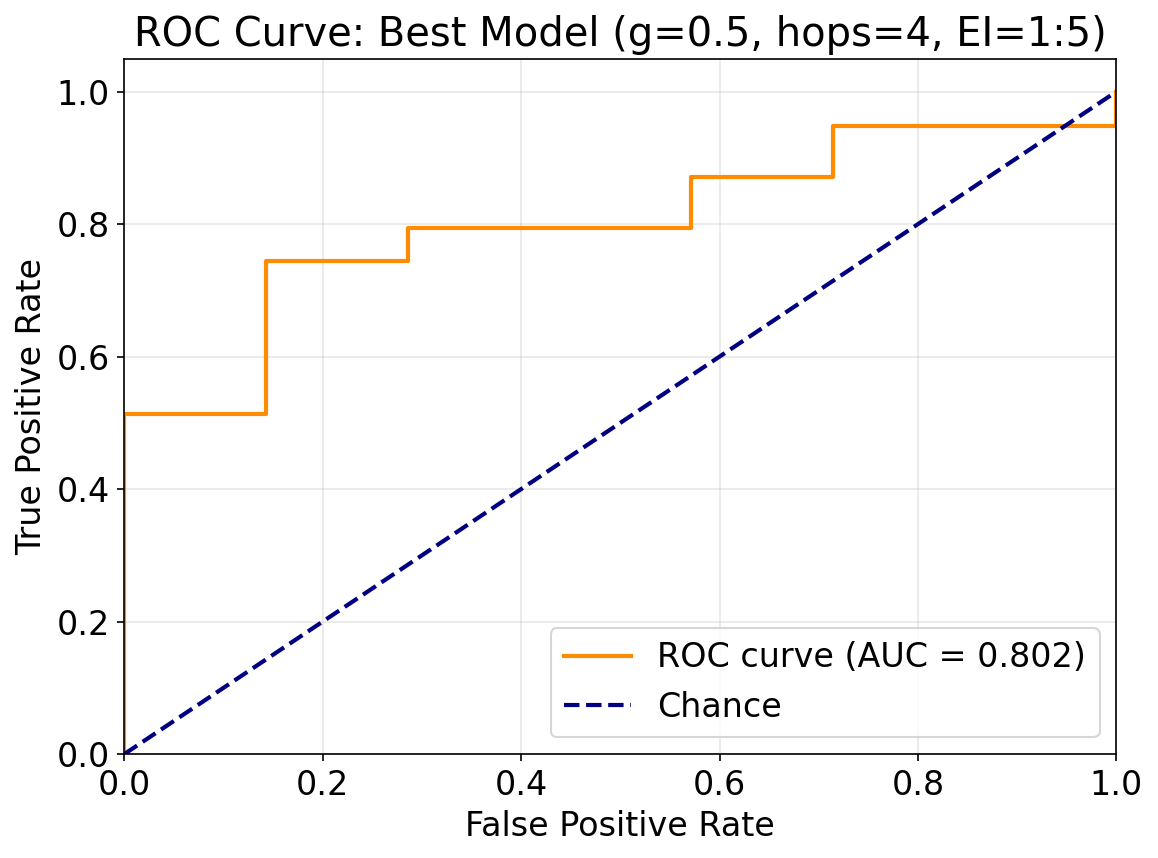

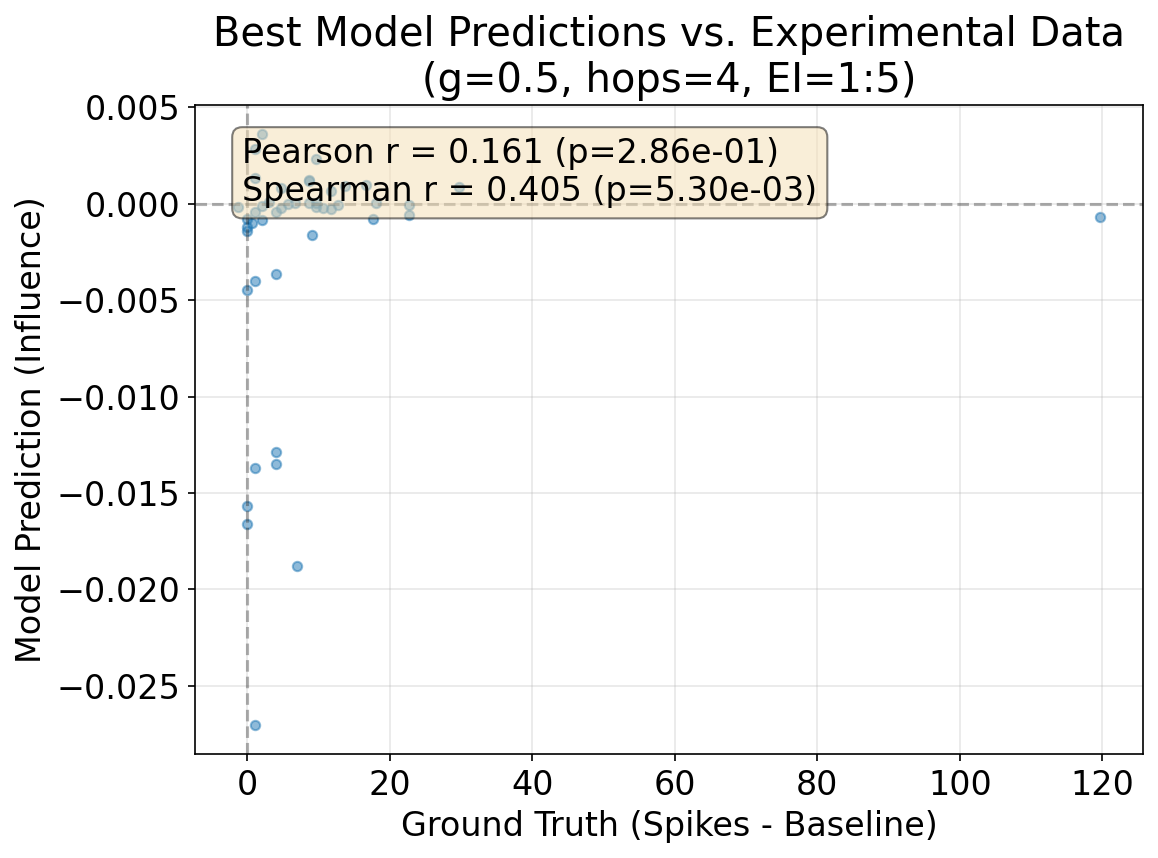


Correlations:
  Pearson r: 0.161 (p=2.86e-01)
  Spearman r: 0.405 (p=5.30e-03)


In [19]:
# ▶ ROC Analysis
from sklearn.metrics import roc_curve, auc, roc_auc_score
import matplotlib.pyplot as plt

print('Performing ROC analysis...')

# Collect all predictions and ground truth across all LHN types and odors
all_predictions = []
all_ground_truth = []
all_labels = []  # Binary: 1 if response > threshold, 0 otherwise

# Threshold for considering a response "active"
response_threshold = 0.0  # Spikes above baseline

# Use best model predictions
for lhn_type in predictions_best.keys():
    for odor in predictions_best[lhn_type].keys():
        if odor in ground_truth_best[lhn_type]:
            pred = predictions_best[lhn_type][odor]
            true = ground_truth_best[lhn_type][odor]
            
            all_predictions.append(pred)
            all_ground_truth.append(true)
            all_labels.append(1 if true > response_threshold else 0)

all_predictions = np.array(all_predictions)
all_ground_truth = np.array(all_ground_truth)
all_labels = np.array(all_labels)

print(f'Total prediction-observation pairs: {len(all_predictions)}')
print(f'Active responses (above baseline): {all_labels.sum()} ({100*all_labels.mean():.1f}%)')
print(f'Inactive responses: {(~all_labels.astype(bool)).sum()} ({100*(1-all_labels.mean()):.1f}%)')

# Compute ROC curve
if len(np.unique(all_labels)) > 1:
    fpr, tpr, thresholds = roc_curve(all_labels, all_predictions)
    roc_auc = auc(fpr, tpr)
    
    print(f'\n✓ ROC AUC: {roc_auc:.3f}')
    
    # Plot ROC curve
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, 
             label=f'ROC curve (AUC = {roc_auc:.3f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Chance')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve: Best Model (g={best_params["g"]}, hops={int(best_params["n_hops"])}, EI=1:{int(best_params["ei_ratio"])})')
    plt.legend(loc='lower right')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # Scatter plot: predictions vs ground truth
    plt.figure(figsize=(8, 6))
    plt.scatter(all_ground_truth, all_predictions, alpha=0.5, s=20)
    plt.xlabel('Ground Truth (Spikes - Baseline)')
    plt.ylabel('Model Prediction (Influence)')
    plt.title(f'Best Model Predictions vs. Experimental Data\n(g={best_params["g"]}, hops={int(best_params["n_hops"])}, EI=1:{int(best_params["ei_ratio"])})')
    plt.axhline(y=0, color='k', linestyle='--', alpha=0.3)
    plt.axvline(x=0, color='k', linestyle='--', alpha=0.3)
    plt.grid(alpha=0.3)
    
    # Add correlation
    from scipy.stats import pearsonr, spearmanr
    pearson_r, pearson_p = pearsonr(all_ground_truth, all_predictions)
    spearman_r, spearman_p = spearmanr(all_ground_truth, all_predictions)
    
    plt.text(0.05, 0.95, 
             f'Pearson r = {pearson_r:.3f} (p={pearson_p:.2e})\n' +
             f'Spearman r = {spearman_r:.3f} (p={spearman_p:.2e})',
             transform=plt.gca().transAxes,
             verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.tight_layout()
    plt.show()
    
    print(f'\nCorrelations:')
    print(f'  Pearson r: {pearson_r:.3f} (p={pearson_p:.2e})')
    print(f'  Spearman r: {spearman_r:.3f} (p={spearman_p:.2e})')
else:
    print('\n⚠️  Cannot compute ROC: only one class present in ground truth')